In [2]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from scipy.stats import ttest_ind
import statsmodels.stats.api as sms
%run ../functions/Transfer_longitude.ipynb
%run ../functions/Yearly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/mask_land_ocean.ipynb
%run ../functions/Moving_mean.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data and calculate the difference

In [3]:
def read_and_diff(route):
    # Read the SAT from the reference run
    diri='/zhoulab_rit/lzhuo/data/Modelling/Clim/'
    filename='TREFHT.nc'
    fi=xr.open_dataset(diri+filename)
    t2m=fi.TREFHT
    ## Transfer the longitude
    T2m=central180_to_0(t2m)
    ## Redefine the time coordinate
    T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
    ## Calculate the boreal warm season mean
    T2m_ctl=weighted_mean_multiple(T2m)
    ## Calculate the mean over the Sahara
    T2m_SD_ctl=T2m_ctl.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])
    
    # Read the data from the sensitivity run
    diri=route
    # diri='/zhoulab_rit/lzhuo/data/Modelling/Med_season_SST/'
    filename='TREFHT.nc'
    fi=xr.open_dataset(diri+filename)
    t2m=fi.TREFHT
    ## Transfer the longitude
    T2m=central180_to_0(t2m)
    ## Redefine the time coordinate
    T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
    ## Calculate the boreal warm season mean
    T2m_sen=weighted_mean_multiple(T2m)
    ## Calculate the mean over the Sahara
    T2m_SD_sen=T2m_sen.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])
    
    # Calculate the difference
    T2m_SD_diff=T2m_SD_sen-T2m_SD_ctl
    
    # Calculate the 95% confidence interval
    cm = sms.CompareMeans(sms.DescrStatsW(T2m_SD_sen), sms.DescrStatsW(T2m_SD_ctl))
    ci_low, ci_high = cm.tconfint_diff(usevar='unequal')  # or 'pooled' for equal variances
    
    # Calculate the half of the confidence interval
    half_interval=(ci_high-ci_low)/2
    return T2m_SD_diff,half_interval

In [4]:
Full,Full_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Full_season_SST/')
Null,Null_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Null_season_SST/')
Med,Med_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Med_season_SST/')
Car,Car_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Car_season_SST/')
# Car,Car_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Car_season_SST_new_5/')
Atl,Atl_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Atlantic_season_SST_1/')
Ind,Ind_half_interval=read_and_diff('/zhoulab_rit/lzhuo/data/Modelling/Ind_season_SST/')

## Plot

In [7]:
y=np.array([Full.mean(dim='year'),Med.mean(dim='year'),Car.mean(dim='year'),Atl.mean(dim='year'),Ind.mean(dim='year')])
err=[Full_half_interval,Med_half_interval,Car_half_interval,Atl_half_interval,Ind_half_interval]

(-1.5, 4.5)

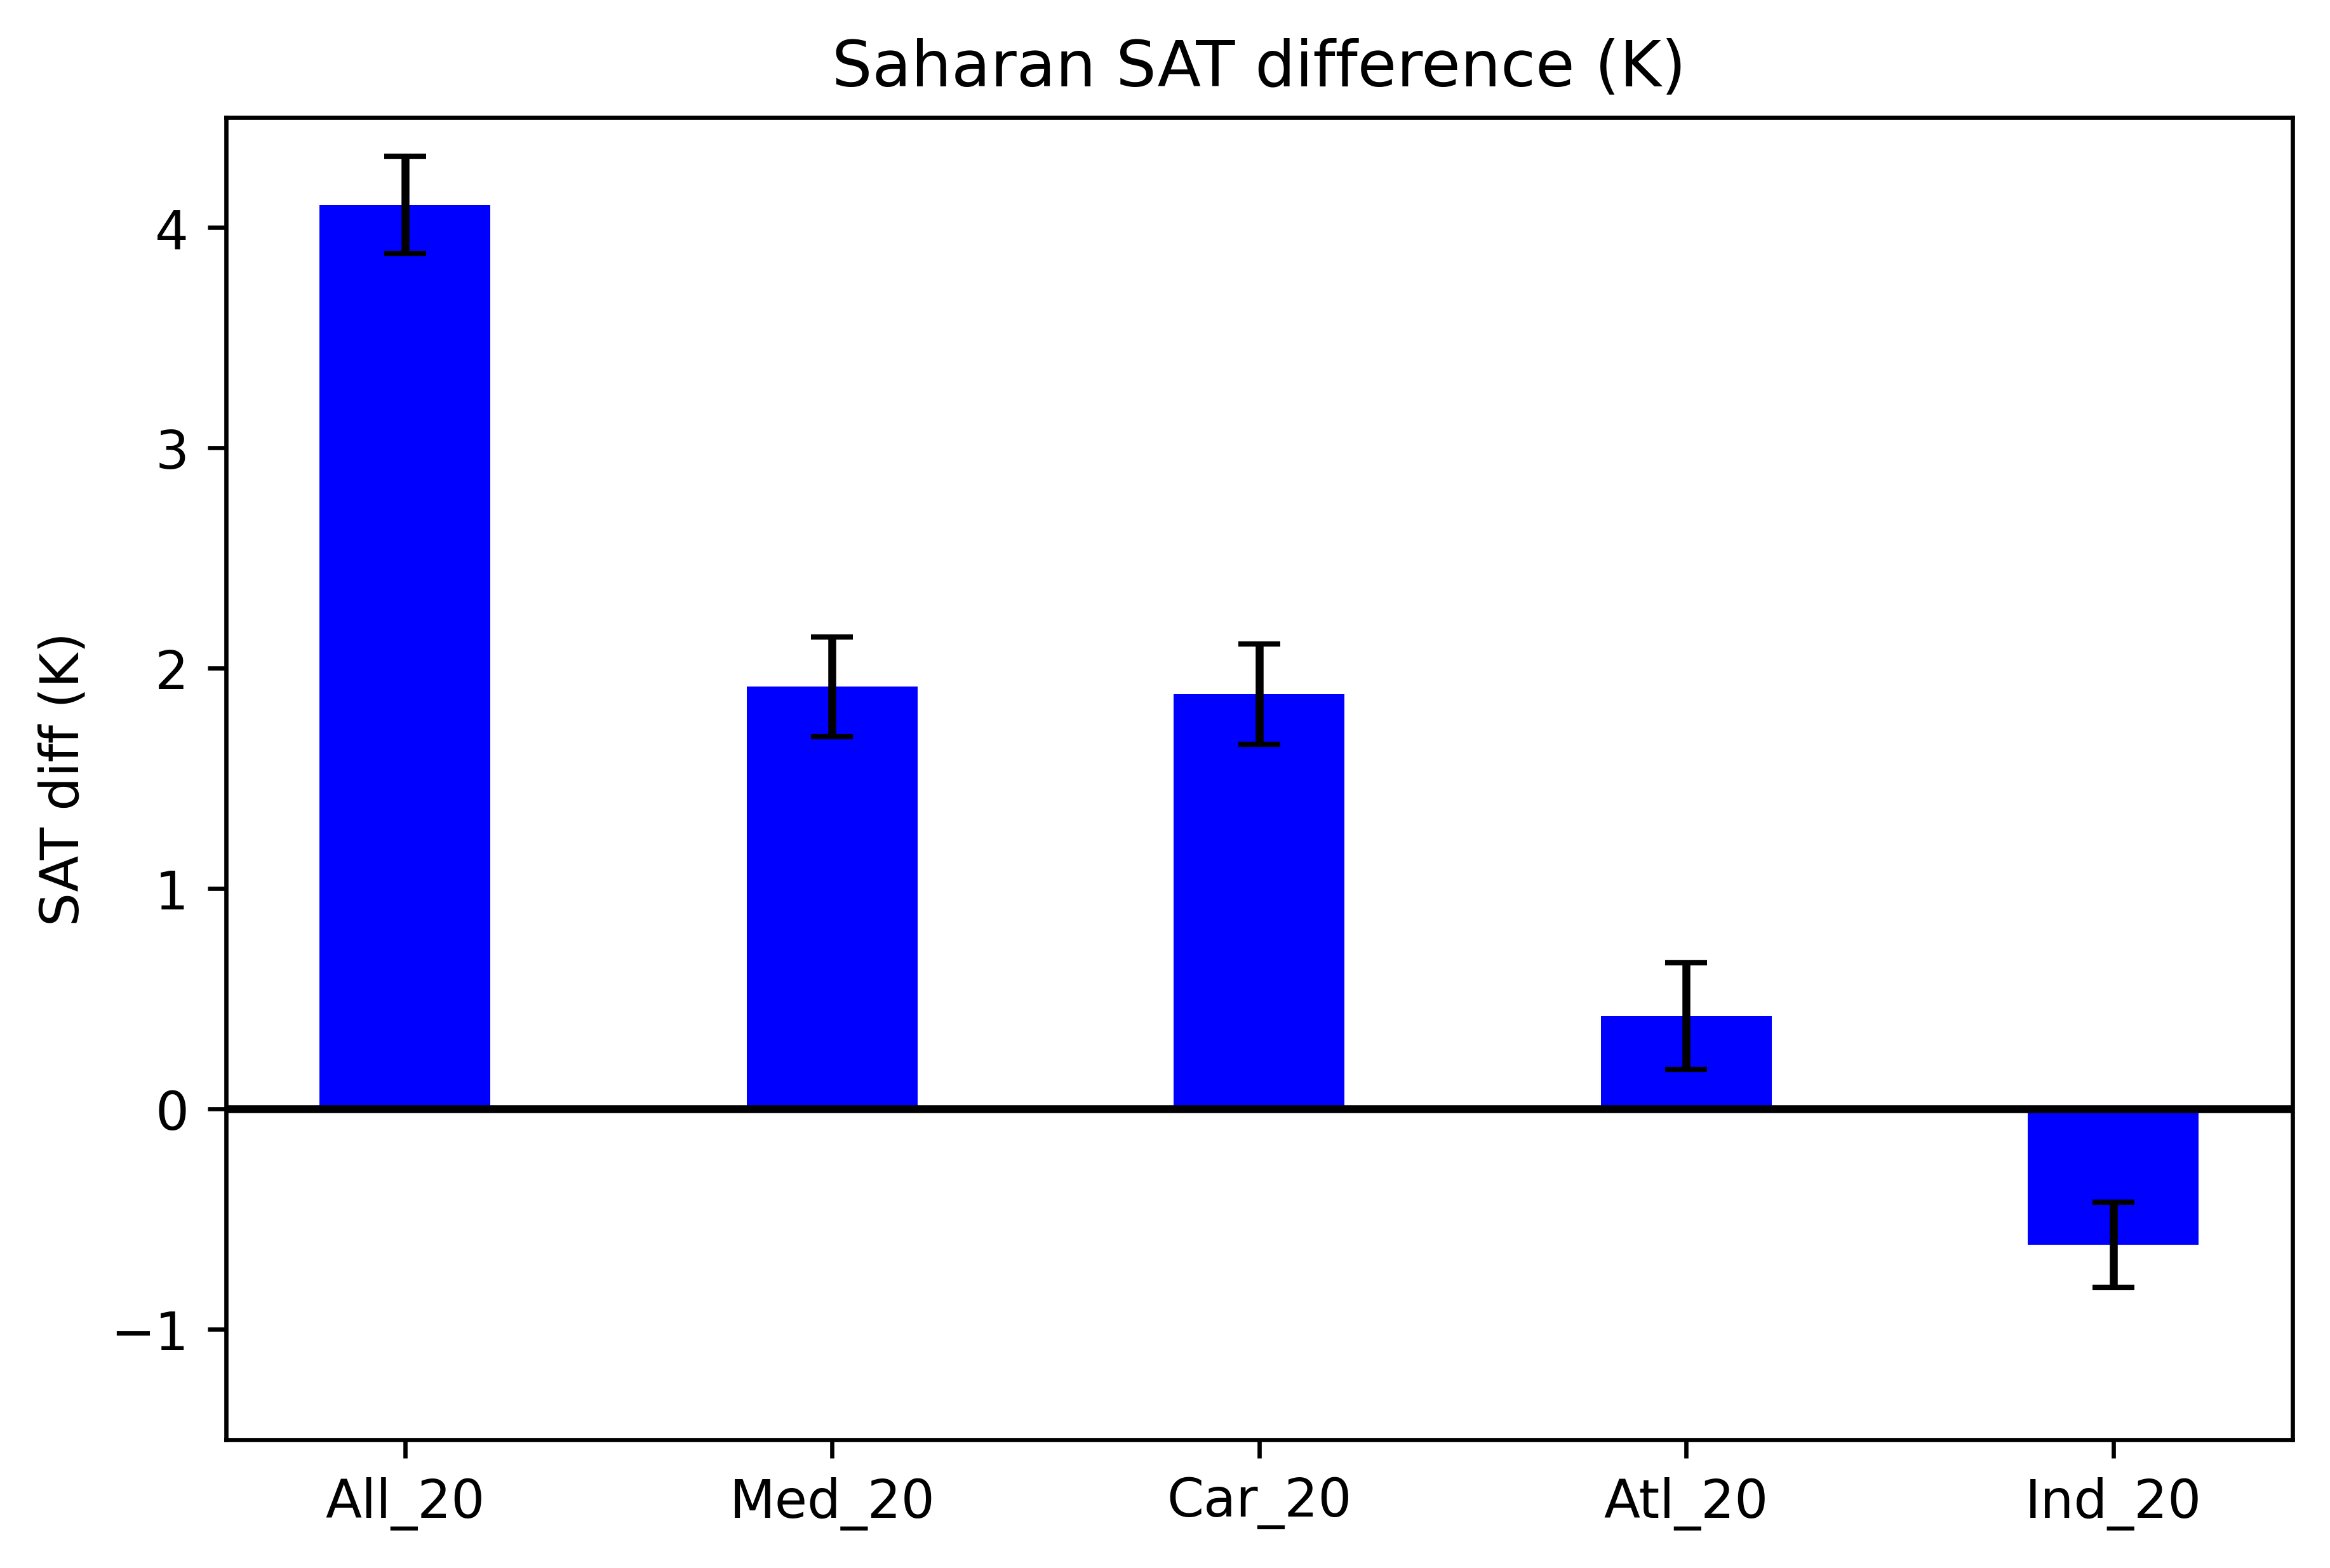

In [9]:
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])
x=np.arange(1,6)
# y=data.tolist()
width=0.4
ax.bar(x, y,color='blue',width=width,yerr=err,capsize=4)
# x=x+width
# y=Feedback_T_Tropics_land.tolist()
# ax.bar(x, y,color='red',width=width,label='Tropical land')
# x=x-width/2
labels=['All_20','Med_20','Car_20','Atl_20','Ind_20']
ax.set_xticks(x, labels)
ax.set_ylabel('SAT diff (K)')
# ax.set_ylim([-0.5,0.8])
ax.axhline(y = 0, color = 'k', linestyle = '-')
ax.set_title('Saharan SAT difference (K)')
ax.set_ylim([-1.5,4.5])